<a href="https://colab.research.google.com/github/githubtaniya924/Image-Processing-Projects/blob/main/IP_Practical8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

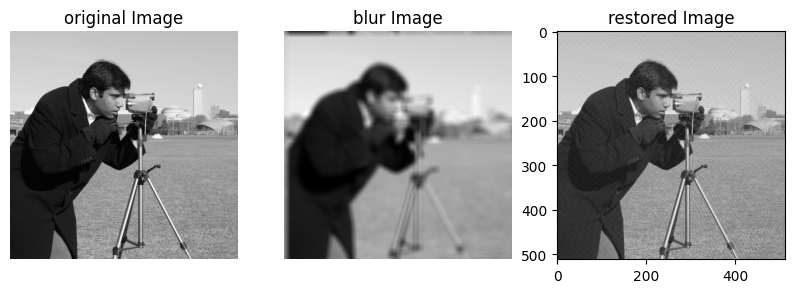

In [ ]:
#inverse filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data
from numpy.fft import fft2,ifft2

#Load built-in graysacle image
original = data.camera().astype(np.float64)

#Create a simple blur (degradation function)
def blur_kernel(size=15):
  kernel = np.ones((size,size))/(size*size)
  return kernel

#Pad kernel to image size
kernel = blur_kernel(15)
kernel_padded = np.zeros_like(original)
k=kernel.shape[0]
kernel_padded[:k,:k]=kernel

#Fourier transform
F = fft2(original)
H = fft2(kernel_padded)

#Create blurred image
G = F*H
blurred = np.real(ifft2(G))

#Inverse Filtering (avoid division by zero)
epsilon = 1e-3
H_inv = 1/(H+epsilon)
F_restored = G* H_inv
restorted = np.real(ifft2(F_restored))

#Display results
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("original Image")
plt.imshow(original, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("blur Image")
plt.imshow(blurred, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("restored Image")
plt.imshow(restorted, cmap='gray')

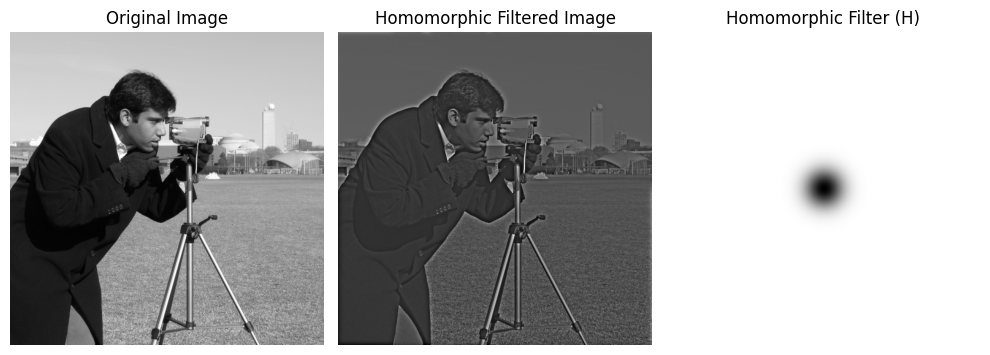

In [ ]:
#Homomorphic Filter
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from numpy.fft import fft2, ifft2, fftshift, ifftshift

# Load image
image = data.camera().astype(np.float64)
image = image / 255.0  # normalize

# Take log transform
log_image = np.log1p(image)

# Fourier Transform
F = fftshift(fft2(log_image))

# Create Homomorphic Filter
rows, cols = image.shape
u = np.arange(rows)
v = np.arange(cols)
U, V = np.meshgrid(u, v, indexing='ij')

D = np.sqrt((U - rows/2)**2 + (V - cols/2)**2)

# Filter parameters
gamma_L = 0.5   # low-frequency gain
gamma_H = 2.0   # high-frequency gain
c = 1.0
D0 = 30         # cutoff frequency

# Homomorphic filter equation
H = (gamma_H - gamma_L) * (1 - np.exp(-c * (D**2 / D0**2))) + gamma_L

# Apply filter
G = H * F

# Inverse Fourier Transform
filtered = np.real(ifft2(ifftshift(G)))

# Exponential to get final image
homomorphic_image = np.expm1(filtered)

# Display results
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Homomorphic Filtered Image")
plt.imshow(homomorphic_image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Homomorphic Filter (H)")
plt.imshow(H, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
